In [ ]:
# ============================================
# Imports and Configuration
# ============================================
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
import os
from pathlib import Path

# --- Reproducibility ---
# Setting seeds ensures you get same results each run
tf.random.set_seed(42)
np.random.seed(42)

# --- Configuration (change these in one place) ---
DATASET_PATH = Path("../dataset/plantvillage dataset/color")
IMG_SIZE     = 224      # Height and width of input images
BATCH_SIZE   = 32       # Images per training step
EPOCHS       = 10       # How many times to go through full dataset
NUM_CLASSES  = 38       # Total disease categories
SEED         = 42

print(f"✅ TensorFlow version: {tf.__version__}")
print(f"✅ Configuration loaded")
print(f"   IMG_SIZE:    {IMG_SIZE}x{IMG_SIZE}")
print(f"   BATCH_SIZE:  {BATCH_SIZE}")
print(f"   EPOCHS:      {EPOCHS}")
print(f"   NUM_CLASSES: {NUM_CLASSES}")

✅ TensorFlow version: 2.16.2
✅ Configuration loaded
   IMG_SIZE:    224x224
   BATCH_SIZE:  32
   EPOCHS:      10
   NUM_CLASSES: 38


In [ ]:
# ============================================
# Load dataset with augmentation
# ============================================

# --- Augmentation (applied only during training) ---
# This runs ON THE GPU during training — very efficient
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomContrast(0.1),
], name="data_augmentation")

# --- Load Training Data ---
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="training",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# --- Load Validation Data ---
val_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_PATH,
    validation_split=0.2,
    subset="validation",
    seed=SEED,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    label_mode='categorical'
)

# --- Save class names ---
class_names = train_ds.class_names
print(f"✅ Classes loaded: {len(class_names)}")

# --- Optimize pipeline ---
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(AUTOTUNE)
val_ds   = val_ds.prefetch(AUTOTUNE)

print("✅ Dataset ready!")

2026-03-20 11:36:13.034750: I metal_plugin/src/device/metal_device.cc:1154] Metal device set to: Apple M1
2026-03-20 11:36:13.034785: I metal_plugin/src/device/metal_device.cc:296] systemMemory: 8.00 GB
2026-03-20 11:36:13.034789: I metal_plugin/src/device/metal_device.cc:313] maxCacheSize: 2.67 GB
2026-03-20 11:36:13.034807: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:305] Could not identify NUMA node of platform GPU ID 0, defaulting to 0. Your kernel may not have been built with NUMA support.
2026-03-20 11:36:13.034820: I tensorflow/core/common_runtime/pluggable_device/pluggable_device_factory.cc:271] Created TensorFlow device (/job:localhost/replica:0/task:0/device:GPU:0 with 0 MB memory) -> physical PluggableDevice (device: 0, name: METAL, pci bus id: <undefined>)


Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
✅ Classes loaded: 38
✅ Dataset ready!


In [ ]:
# ============================================
# CNN From Scratch
# Build every layer manually to understand
# what's happening inside
# ============================================

def build_cnn_scratch(num_classes, img_size=224):
    """
    A simple CNN built from scratch.
    Architecture: Conv → Pool → Conv → Pool → Dense → Output
    """
    model = tf.keras.Sequential([

        # --- Input & Normalization ---
        # Rescale pixels from 0-255 to 0-1
        # Done inside model so it's part of deployment too
        tf.keras.layers.Rescaling(1./255,
                                   input_shape=(img_size, img_size, 3)),

        # --- Block 1: First convolution ---
        # 32 filters, each 3x3, detect basic features
        tf.keras.layers.Conv2D(32, (3,3),
                                activation='relu',
                                padding='same'),
        # MaxPooling: shrink from 224x224 → 112x112
        # Keeps the strongest feature in each 2x2 region
        tf.keras.layers.MaxPooling2D(2, 2),

        # --- Block 2: More complex features ---
        # 64 filters now — detecting more complex patterns
        tf.keras.layers.Conv2D(64, (3,3),
                                activation='relu',
                                padding='same'),
        # Shrink from 112x112 → 56x56
        tf.keras.layers.MaxPooling2D(2, 2),

        # --- Block 3: Even more complex ---
        tf.keras.layers.Conv2D(128, (3,3),
                                activation='relu',
                                padding='same'),
        # Shrink from 56x56 → 28x28
        tf.keras.layers.MaxPooling2D(2, 2),

        # --- Block 4: Deep features ---
        tf.keras.layers.Conv2D(256, (3,3),
                                activation='relu',
                                padding='same'),
        # Shrink from 28x28 → 14x14
        tf.keras.layers.MaxPooling2D(2, 2),

        # --- Flatten: 2D → 1D ---
        # Convert feature maps into a flat vector
        # 14 × 14 × 256 = 50,176 values
        tf.keras.layers.Flatten(),

        # --- Dropout: prevents overfitting ---
        # Randomly turns off 50% of neurons during training
        # Forces network to learn redundant representations
        tf.keras.layers.Dropout(0.5),

        # --- Dense: classification head ---
        # 512 neurons combine all detected features
        tf.keras.layers.Dense(512, activation='relu'),
        tf.keras.layers.Dropout(0.3),

        # --- Output layer ---
        # 38 neurons = 38 disease classes
        # Softmax converts to probabilities (all sum to 1.0)
        tf.keras.layers.Dense(num_classes, activation='softmax')

    ], name="CNN_from_scratch")

    return model

# Build and display the model
cnn_scratch = build_cnn_scratch(NUM_CLASSES, IMG_SIZE)
cnn_scratch.summary()

/opt/anaconda3/envs/cropenv/lib/python3.10/site-packages/keras/src/layers/preprocessing/data_layer.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "CNN_from_scratch"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 512)            │    25,690,624 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │        19,494 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 26,098,534 (99.56 MB)

 Trainable params: 26,098,534 (99.56 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# ============================================
# Compile the model
# ============================================

cnn_scratch.compile(
    # Adam: smart optimizer that adjusts learning rate
    # automatically — best default choice
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

    # categorical_crossentropy: standard loss for
    # multi-class classification problems
    loss='categorical_crossentropy',

    # Track accuracy during training
    metrics=['accuracy']
)

print("✅ Model compiled!")
print(f"   Optimizer: Adam (lr=0.001)")
print(f"   Loss:      Categorical Crossentropy")
print(f"   Metric:    Accuracy")

✅ Model compiled!
   Optimizer: Adam (lr=0.001)
   Loss:      Categorical Crossentropy
   Metric:    Accuracy


In [ ]:
# ============================================
# Train CNN from scratch
# ============================================

# --- Callbacks: smart training helpers ---

# Stop training early if model stops improving
# Saves you time and prevents overfitting
early_stopping = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',   # Watch validation accuracy
    patience=3,               # Stop if no improvement for 3 epochs
    restore_best_weights=True # Roll back to best weights
)

# Save the best model automatically during training
checkpoint = tf.keras.callbacks.ModelCheckpoint(
    '../model/cnn_scratch_best.keras',
    monitor='val_accuracy',
    save_best_only=True,      # Only save when it improves
    verbose=1
)

# Reduce learning rate when stuck
# Helps model fine-tune when it plateaus
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,               # Multiply lr by 0.2
    patience=2,
    min_lr=1e-7,
    verbose=1
)

print("🚀 Starting training...")
print("   This will take a few minutes...\n")

# --- Train! ---
history_scratch = cnn_scratch.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds,
    callbacks=[early_stopping, checkpoint, reduce_lr],
    verbose=1
)

print("\n✅ Training complete!")

🚀 Starting training...
   This will take a few minutes...

Epoch 1/10


2026-03-20 11:37:06.268840: I tensorflow/core/grappler/optimizers/custom_graph_optimizer_registry.cc:117] Plugin optimizer for device_type GPU is enabled.


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 248ms/step - accuracy: 0.4533 - loss: 2.2223
Epoch 1: val_accuracy improved from None to 0.67876, saving model to ../model/cnn_scratch_best.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 361s 262ms/step - accuracy: 0.5772 - loss: 2.0042 - val_accuracy: 0.6788 - val_loss: 2.7577 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 255ms/step - accuracy: 0.6927 - loss: 3.1542
Epoch 2: val_accuracy improved from 0.67876 to 0.77544, saving model to ../model/cnn_scratch_best.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 366s 270ms/step - accuracy: 0.7066 - loss: 4.1958 - val_accuracy: 0.7754 - val_loss: 4.6541 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 284ms/step - accuracy: 0.7408 - loss: 12.5325
Epoch 3: val_accuracy improved from 0.77544 to 0.82727, saving model to ../model/cnn_scratch_best.keras

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 408s 300ms/step - accuracy: 

2026-03-20 13:20:28.516 python[48196:742248] Error creating directory 
 The volume ‚ÄúMacintosh HD‚Äù is out of space. You can‚Äôt save the file ‚Äúmpsgraph-48196-2026-03-20_13_20_27-1643946469‚Äù because the volume ‚ÄúMacintosh HD‚Äù is out of space.


1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 622ms/step - accuracy: 0.9029 - loss: 21.6373
Epoch 9: val_accuracy improved from 0.93316 to 0.93352, saving model to ../model/cnn_scratch_best.keras

Epoch 9: ReduceLROnPlateau reducing learning rate to 1.6000001778593287e-06.
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 860s 634ms/step - accuracy: 0.9050 - loss: 20.1741 - val_accuracy: 0.9335 - val_loss: 13.3844 - learning_rate: 8.0000e-06
Epoch 10/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 293ms/step - accuracy: 0.8978 - loss: 23.0875
Epoch 10: val_accuracy improved from 0.93352 to 0.93426, saving model to ../model/cnn_scratch_best.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 423s 311ms/step - accuracy: 0.9014 - loss: 20.9464 - val_accuracy: 0.9343 - val_loss: 13.3611 - learning_rate: 1.6000e-06

✅ Training complete!


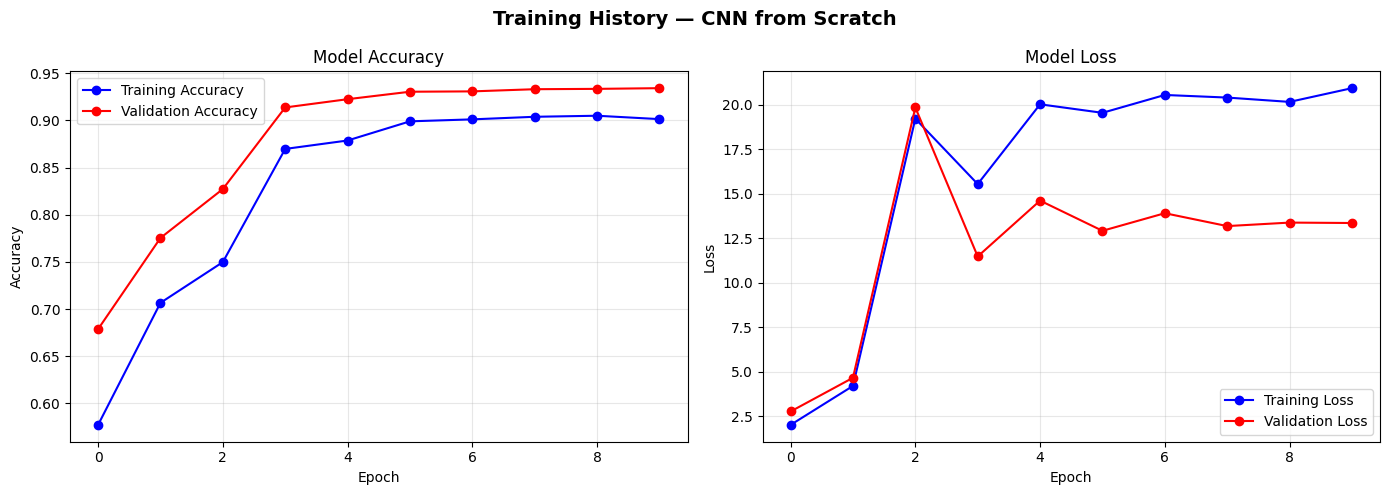

📊 Final Training Accuracy:   90.14%
📊 Final Validation Accuracy: 93.43%


In [ ]:
# ============================================
# Visualize training history
# ============================================

def plot_training_history(history, title="CNN from Scratch"):
    acc     = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss     = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    fig.suptitle(f'Training History — {title}',
                 fontsize=14, fontweight='bold')

    # --- Accuracy plot ---
    axes[0].plot(epochs_range, acc,     'b-o', label='Training Accuracy')
    axes[0].plot(epochs_range, val_acc, 'r-o', label='Validation Accuracy')
    axes[0].set_title('Model Accuracy')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Accuracy')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    # --- Loss plot ---
    axes[1].plot(epochs_range, loss,     'b-o', label='Training Loss')
    axes[1].plot(epochs_range, val_loss, 'r-o', label='Validation Loss')
    axes[1].set_title('Model Loss')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Loss')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('../report/training_history_scratch.png',
                dpi=150, bbox_inches='tight')
    plt.show()

    # Print final results
    print(f"📊 Final Training Accuracy:   {acc[-1]*100:.2f}%")
    print(f"📊 Final Validation Accuracy: {val_acc[-1]*100:.2f}%")

plot_training_history(history_scratch, "CNN from Scratch")

In [ ]:
# ============================================
# Transfer Learning with MobileNetV2
# ============================================

# --- Step 1: Load MobileNetV2 pretrained on ImageNet ---
# include_top=False means we remove the final
# classification layer (it was for 1000 ImageNet classes)
# We'll add our own for 38 disease classes
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,        # Remove ImageNet classifier
    weights='imagenet'        # Use pretrained weights
)

# --- Step 2: Freeze the base model ---
# We don't want to change what MobileNetV2 already learned
# Freezing = weights won't update during training
base_model.trainable = False

print(f"✅ MobileNetV2 loaded")
print(f"   Total layers: {len(base_model.layers)}")
print(f"   Trainable params: {sum([tf.size(w).numpy() for w in base_model.trainable_weights]):,}")
print(f"   Non-trainable params: {sum([tf.size(w).numpy() for w in base_model.non_trainable_weights]):,}")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 14s 1us/step
✅ MobileNetV2 loaded
   Total layers: 154
   Trainable params: 0
   Non-trainable params: 2,257,984


In [ ]:
# ============================================
# Add our custom layers on top
# ============================================

# Build the full model using Functional API
# (more flexible than Sequential for complex models)

# --- Input ---
inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))

# --- Rescale pixels 0-255 → 0-1 ---
x = tf.keras.layers.Rescaling(1./255)(inputs)

# --- Data augmentation (only active during training) ---
x = data_augmentation(x, training=True)

# --- MobileNetV2 preprocessing ---
# MobileNetV2 expects pixels in range [-1, 1]
x = tf.keras.applications.mobilenet_v2.preprocess_input(x * 255)

# --- Base model (frozen) ---
x = base_model(x, training=False)

# --- Global Average Pooling ---
# Converts 7x7x1280 feature maps → 1280 values
# Much better than Flatten for transfer learning
x = tf.keras.layers.GlobalAveragePooling2D()(x)

# --- Batch Normalization ---
# Normalizes activations — stabilizes training
x = tf.keras.layers.BatchNormalization()(x)

# --- Dense layers (our custom classifier) ---
x = tf.keras.layers.Dense(256, activation='relu')(x)
x = tf.keras.layers.Dropout(0.4)(x)
x = tf.keras.layers.Dense(128, activation='relu')(x)
x = tf.keras.layers.Dropout(0.3)(x)

# --- Output: 38 disease classes ---
outputs = tf.keras.layers.Dense(
    NUM_CLASSES,
    activation='softmax'
)(x)

# --- Assemble model ---
mobilenet_model = tf.keras.Model(
    inputs=inputs,
    outputs=outputs,
    name="MobileNetV2_Transfer"
)

mobilenet_model.summary()

Model: "MobileNetV2_Transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ data_augmentation (Sequential)  │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ multiply (Multiply)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ true_divide (TrueDivide)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ subtract (Subtract)             │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 1280)           │         5,120 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 256)            │       327,936 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,628,838 (10.03 MB)

 Trainable params: 368,294 (1.40 MB)

 Non-trainable params: 2,260,544 (8.62 MB)

In [ ]:
# ============================================
# Phase 1 Training — Frozen base
# Only our custom layers learn here
# Fast! Only 400K params to train
# ============================================

mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# Callbacks
checkpoint_mobilenet = tf.keras.callbacks.ModelCheckpoint(
    '../model/mobilenet_best.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.3,
    patience=2,
    min_lr=1e-7,
    verbose=1
)

print("🚀 Phase 1: Training custom layers only...")
print("   Base model is FROZEN — fast training!\n")

history_phase1 = mobilenet_model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[checkpoint_mobilenet, early_stop, reduce_lr],
    verbose=1
)

print("\n✅ Phase 1 complete!")
print(f"   Best val accuracy: {max(history_phase1.history['val_accuracy'])*100:.2f}%")

🚀 Phase 1: Training custom layers only...
   Base model is FROZEN — fast training!

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 252ms/step - accuracy: 0.6332 - loss: 1.8651
Epoch 1: val_accuracy improved from None to 0.89531, saving model to ../model/mobilenet_best.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 428s 309ms/step - accuracy: 0.7222 - loss: 1.4185 - val_accuracy: 0.8953 - val_loss: 0.4152 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 305ms/step - accuracy: 0.7875 - loss: 1.1717
Epoch 2: val_accuracy did not improve from 0.89531
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 489s 360ms/step - accuracy: 0.7923 - loss: 1.1454 - val_accuracy: 0.8774 - val_loss: 0.4921 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 285ms/step - accuracy: 0.7954 - loss: 1.1544
Epoch 3: val_accuracy did not improve from 0.89531

Epoch 3: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 465s 342ms/step - accuracy: 0.7981 - loss: 

In [ ]:
# ============================================
# Phase 2 — Fine Tuning
# Unfreeze top layers of MobileNetV2
# Let them adapt to leaf disease features
# ============================================

# Unfreeze the top 30 layers of base model
base_model.trainable = True
total_layers = len(base_model.layers)
fine_tune_from = total_layers - 30  # Unfreeze last 30 layers

for layer in base_model.layers[:fine_tune_from]:
    layer.trainable = False   # Keep early layers frozen
for layer in base_model.layers[fine_tune_from:]:
    layer.trainable = True    # Unfreeze last 30 layers

# Count trainable params after unfreezing
trainable = sum([tf.size(w).numpy()
                 for w in mobilenet_model.trainable_weights])
print(f"✅ Fine-tuning from layer {fine_tune_from}/{total_layers}")
print(f"   Trainable parameters now: {trainable:,}")

# CRITICAL: Use very low learning rate for fine-tuning
# High lr would destroy the pretrained weights!
mobilenet_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

checkpoint_finetune = tf.keras.callbacks.ModelCheckpoint(
    '../model/mobilenet_finetuned.keras',
    monitor='val_accuracy',
    save_best_only=True,
    verbose=1
)

early_stop_ft = tf.keras.callbacks.EarlyStopping(
    monitor='val_accuracy',
    patience=4,
    restore_best_weights=True,
    verbose=1
)

print("\n🚀 Phase 2: Fine-tuning top layers...")
print("   Using very low learning rate (1e-5)\n")

history_phase2 = mobilenet_model.fit(
    train_ds,
    epochs=10,
    validation_data=val_ds,
    callbacks=[checkpoint_finetune, early_stop_ft],
    verbose=1
)

print("\n✅ Fine-tuning complete!")
print(f"   Best val accuracy: {max(history_phase2.history['val_accuracy'])*100:.2f}%")

✅ Fine-tuning from layer 124/154
   Trainable parameters now: 1,894,694

🚀 Phase 2: Fine-tuning top layers...
   Using very low learning rate (1e-5)

Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 520ms/step - accuracy: 0.7738 - loss: 1.1463
Epoch 1: val_accuracy improved from None to 0.89808, saving model to ../model/mobilenet_finetuned.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 821s 595ms/step - accuracy: 0.7981 - loss: 0.9767 - val_accuracy: 0.8981 - val_loss: 0.3970
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 446ms/step - accuracy: 0.8317 - loss: 0.7470
Epoch 2: val_accuracy improved from 0.89808 to 0.91400, saving model to ../model/mobilenet_finetuned.keras
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 682s 500ms/step - accuracy: 0.8385 - loss: 0.7048 - val_accuracy: 0.9140 - val_loss: 0.3113
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 4s/step - accuracy: 0.8512 - loss: 0.6480
Epoch 3: val_accuracy improved from 0.91400 to 0.92109, saving model to ../model/mobilenet_finetuned.keras
1358/1358 ━━━━━━━━━

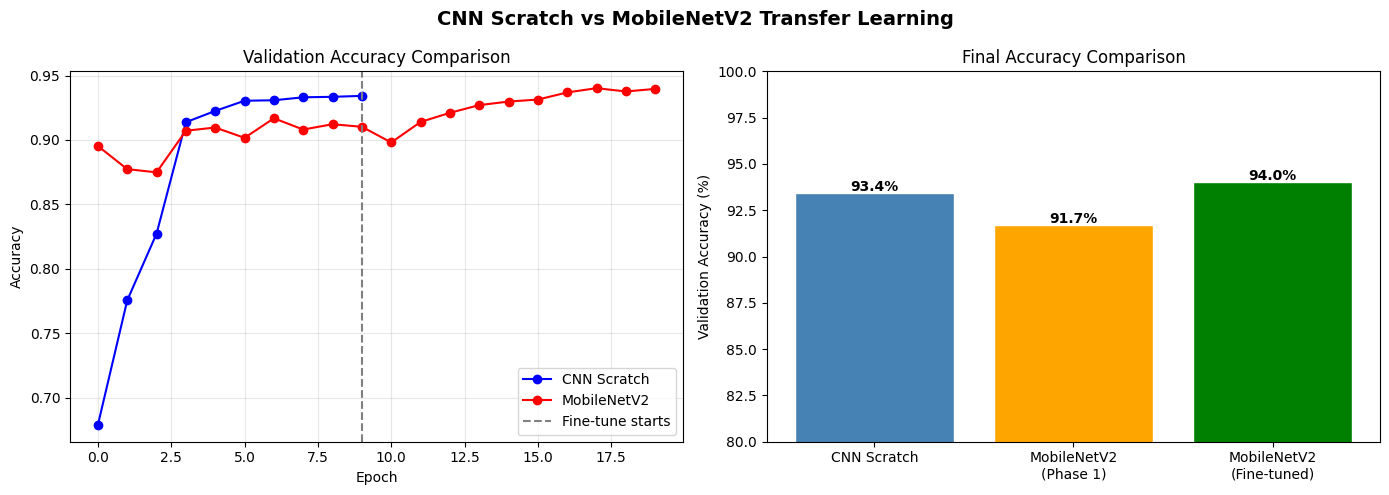

In [ ]:
# ============================================
# Compare CNN Scratch vs MobileNetV2
# ============================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('CNN Scratch vs MobileNetV2 Transfer Learning',
             fontsize=14, fontweight='bold')

# Combine phase 1 + phase 2 history
combined_val_acc = (history_phase1.history['val_accuracy'] +
                    history_phase2.history['val_accuracy'])
combined_acc = (history_phase1.history['accuracy'] +
                history_phase2.history['accuracy'])

scratch_val_acc = history_scratch.history['val_accuracy']

# Accuracy comparison
axes[0].plot(scratch_val_acc, 'b-o', label='CNN Scratch')
axes[0].plot(combined_val_acc, 'r-o', label='MobileNetV2')
axes[0].axvline(x=len(history_phase1.history['val_accuracy'])-1,
                color='gray', linestyle='--', label='Fine-tune starts')
axes[0].set_title('Validation Accuracy Comparison')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Accuracy')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Final accuracy bar chart
models = ['CNN Scratch', 'MobileNetV2\n(Phase 1)',
          'MobileNetV2\n(Fine-tuned)']
accuracies = [
    max(scratch_val_acc) * 100,
    max(history_phase1.history['val_accuracy']) * 100,
    max(history_phase2.history['val_accuracy']) * 100
]
colors = ['steelblue', 'orange', 'green']
bars = axes[1].bar(models, accuracies, color=colors, edgecolor='white')
axes[1].set_title('Final Accuracy Comparison')
axes[1].set_ylabel('Validation Accuracy (%)')
axes[1].set_ylim([80, 100])

# Add value labels on bars
for bar, acc in zip(bars, accuracies):
    axes[1].text(bar.get_x() + bar.get_width()/2.,
                 bar.get_height() + 0.1,
                 f'{acc:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('../report/model_comparison.png',
            dpi=150, bbox_inches='tight')
plt.show()